# Summary Statistics and Visualizations for Stablecoin Depegging

This notebook provides descriptive evidence to motivate the later PCA-based analysis. We focus on how stablecoin prices behave around known stress episodes and on the distribution of peg deviations to illustrate why detecting abnormal movements is important.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
sns.set_theme(style='whitegrid')

## Load and Inspect Data

In [2]:
from pathlib import Path

# Define directory
data_dir = Path("clean_data")

# Find all *_final.parquet files
parquet_files = sorted(data_dir.glob("*_final.parquet"))

if not parquet_files:
    raise FileNotFoundError("No *_final.parquet files found in clean_data/")

# Load and combine
frames = []
for p in parquet_files:
    df = pd.read_parquet(p)
    
    # Ensure symbol column exists
    if "symbol" not in df.columns:
        coin = p.stem.split("_")[0].upper()
        df["symbol"] = coin
    
    frames.append(df)

data = pd.concat(frames, ignore_index=True, sort=False)

# Basic checks
print("\nFinal dataset loaded")
print("Shape:", data.shape)
print("Columns (first 15):", list(data.columns)[:15])
print("Unique coins:", data["symbol"].unique())

display(data.head())


Final dataset loaded
Shape: (8146, 43)
Columns (first 15): ['symbol', 'depeg', 'depeg_future_1d', 'depeg_future_3d', 'depeg_future_5d', 'depeg_future_7d', 'depeg_future_14d', 'depeg_future_30d', 'timestamp', 'timeOpen', 'timeClose', 'timeHigh', 'timeLow', 'open', 'high']
Unique coins: ['DAI' 'USDP' 'USDC' 'USDT' 'UST']


,symbol,depeg,depeg_future_1d,depeg_future_3d,depeg_future_5d,depeg_future_7d,depeg_future_14d,depeg_future_30d,timestamp,timeOpen,...,peg_error,abs_peg_error,price_deviation_5d,price_deviation_30d,downward_price_deviation_5d,downward_price_deviation_30d,fear_greed_index,fear_greed_index_category,fed_funds_rate,Unnamed: 0
0,DAI,0,0,0,0,0,0,1,2020-12-25 23:59:59,2020-12-25,...,0.003095,0.003095,0.002241,0.003375,0.0,0.0,94.0,Extreme Greed,0.09,NaN
1,DAI,0,0,0,0,0,0,1,2020-12-26 23:59:59,2020-12-26,...,0.001908,0.001908,0.002384,0.003295,0.0,0.0,93.0,Extreme Greed,0.09,NaN
2,DAI,0,0,0,0,0,0,1,2020-12-27 23:59:59,2020-12-27,...,0.002892,0.002892,0.002688,0.003300,0.0,0.0,91.0,Extreme Greed,0.09,NaN
3,DAI,0,0,0,0,0,0,1,2020-12-28 23:59:59,2020-12-28,...,0.003464,0.003464,0.002877,0.003333,0.0,0.0,92.0,Extreme Greed,0.09,NaN
4,DAI,0,0,0,0,0,0,1,2020-12-29 23:59:59,2020-12-29,...,0.003313,0.003313,0.002985,0.003311,0.0,0.0,91.0,Extreme Greed,0.09,NaN


In [3]:
# Ensure datetime column
possible_dates = ['timestamp', 'date', 'timeOpen']
date_col = None
for col in possible_dates:
    if col in data.columns:
        date_col = col
        break
if date_col is None:
    raise KeyError('No datetime-like column found; expected one of timestamp/date/timeOpen.')

data[date_col] = pd.to_datetime(data[date_col])

# Ensure stablecoin identifier column
coin_col = None
for col in ['symbol', 'coin', 'stablecoin', 'token']:
    if col in data.columns:
        coin_col = col
        break
if coin_col is None:
    coin_col = 'symbol'
    data[coin_col] = 'UNKNOWN'

# Standardise coin labels
data[coin_col] = data[coin_col].str.upper().replace({'PAX': 'USDP'})

# Price column guess
price_col = None
for col in ['close', 'price', 'closePrice']:
    if col in data.columns:
        price_col = col
        break
if price_col is None:
    raise KeyError('No price column found (expected close/price/closePrice).')

# abs_peg_error
if 'abs_peg_error' not in data.columns:
    data['abs_peg_error'] = (data[price_col] - 1).abs()

# Restrict to requested window
start = pd.Timestamp('2020-11-25')
end = pd.Timestamp('2026-03-19')
data = data[(data[date_col] >= start) & (data[date_col] <= end)].copy()

summary = {
    'date_min': data[date_col].min(),
    'date_max': data[date_col].max(),
    'coins': sorted(data[coin_col].unique()),
}

print('Date range:', summary['date_min'], 'to', summary['date_max'])
print('Unique coins:', summary['coins'])
print('Row counts by coin:')
print(data.groupby(coin_col).size())

Date range: 2020-12-25 23:59:59 to 2026-03-18 23:59:59
Unique coins: ['DAI', 'USDC', 'USDP', 'USDT', 'UST']
Row counts by coin:
symbol
DAI     1910
USDC    1910
USDP    1910
USDT    1910
UST      502
dtype: int64


## Summary Statistics
Baseline peg stability and dispersion metrics by coin.

In [4]:
# Variables to summarise if present
vars_to_check = ['close', 'abs_peg_error', 'volume', 'marketCap']
available = [c for c in vars_to_check if c in data.columns]
if not available:
    raise KeyError('None of the expected variables found for summary statistics.')

summary_stats = (data.groupby(coin_col)[available]
                    .agg(['mean', 'std', 'min', 'max'])
                    .round(4))

print('Variables summarised:', available)
display(summary_stats)

Variables summarised: ['close', 'abs_peg_error', 'volume', 'marketCap']


close                         abs_peg_error                       \
          mean     std     min     max          mean     std  min     max   
symbol                                                                      
DAI     1.0001  0.0011  0.9739  1.0103        0.0005  0.0010  0.0  0.0261   
USDC    1.0000  0.0008  0.9715  1.0105        0.0002  0.0008  0.0  0.0285   
USDP    0.9995  0.0022  0.9900  1.0108        0.0014  0.0017  0.0  0.0108   
USDT    1.0001  0.0007  0.9959  1.0115        0.0005  0.0006  0.0  0.0115   
UST     1.0002  0.0153  0.7934  1.0421        0.0036  0.0149  0.0  0.2066   

              volume                                               marketCap  \
                mean           std           min           max          mean   
symbol                                                                         
DAI     1.595912e+09  5.518536e+09  3.995529e+07  1.172634e+11  5.659968e+09   
USDC    6.444673e+09  5.079910e+09  7.684437e+08  4.453985e+10  4.145004e+10   
USDP    2.169598e+07  4.117534e+07  1.020574e+05  4.302493e+08  5.249355e+08   
USDT    7.183668e+10  4.477721e+10  9.989859e+09  3.443980e+11  9.992944e+10   
UST     1.896467e+08  3.430022e+08  1.438686e+06  4.905955e+09  5.542219e+09   

                                                  
                 std           min           max  
symbol                                            
DAI     1.495555e+09  1.106812e+09  1.037631e+10  
USDC    1.818171e+10  3.536352e+09  7.962920e+10  
USDP    3.980631e+08  4.053694e+07  1.420689e+09  
USDT    4.212759e+10  2.068269e+10  1.871236e+11  
UST     5.625006e+09  1.541340e+08  1.872563e+10

## Figure 1: Price Behaviour around the May 2022 UST Crash
Stablecoins usually hover near the $1 peg, but stress episodes can lead to sharp deviations. This figure visualises the TerraUSD crash to motivate studying depegging risk.

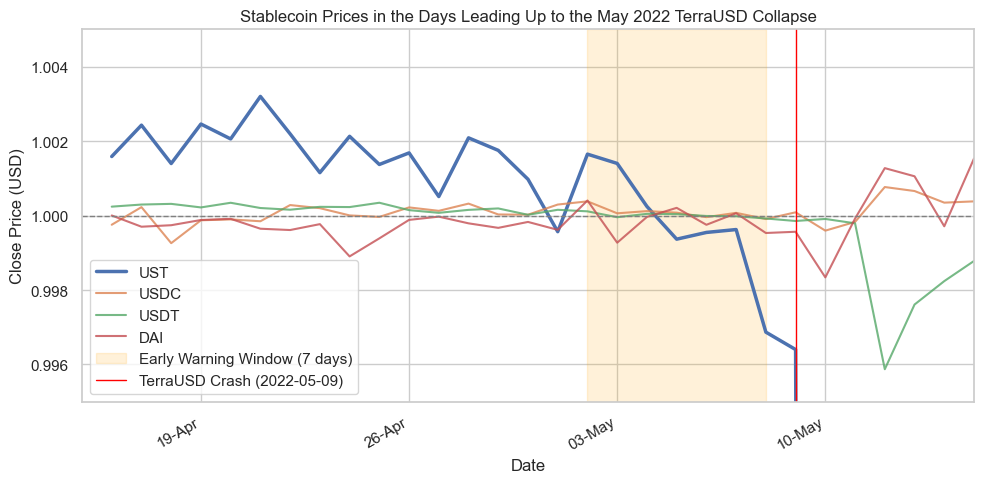

In [5]:
# Define window around crash
crash_window = (pd.Timestamp('2022-04-15'), pd.Timestamp('2022-05-15'))
earliest, latest = crash_window

subset = data[(data[date_col] >= earliest) & (data[date_col] <= latest)]
focus_coins = [c for c in ['UST', 'USDC', 'USDT', 'DAI', 'PAX'] if c in subset[coin_col].unique()]

fig, ax = plt.subplots(figsize=(10,5))
for coin in focus_coins:
    if coin == 'UST':
        tmp = subset[subset[coin_col] == coin]
        ax.plot(tmp[date_col], tmp[price_col], label=coin, linewidth=2.5)
    else: 
        tmp = subset[subset[coin_col] == coin]
        ax.plot(tmp[date_col], tmp[price_col], label=coin, linewidth=1.5, alpha=0.8)

ax.axhline(1.0, color='gray', linestyle='--', linewidth=1)
# Shade early warning window
ax.axvspan(pd.Timestamp('2022-05-02'), pd.Timestamp('2022-05-08'), color='orange', alpha=0.15, label='Early Warning Window (7 days)')
# Terra crash marker
ax.axvline(pd.Timestamp('2022-05-09'), color='red', linestyle='-', linewidth=1, label='TerraUSD Crash (2022-05-09)')

ax.set_xlim(earliest, latest)
ax.set_ylim(0.995, 1.005)
ax.set_ylabel('Close Price (USD)')
ax.set_xlabel('Date')
ax.set_title('Stablecoin Prices in the Days Leading Up to the May 2022 TerraUSD Collapse')
ax.legend(loc='best')
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# Save figure if a plots folder exists
fig_out_dir = None
for candidate in [Path('plots'), Path('stage2_plots')]:
    if candidate.exists():
        fig_out_dir = candidate
        break
if fig_out_dir:
    fig.savefig(fig_out_dir / 'figure1_price_behaviour_may2022.png', dpi=300, bbox_inches='tight')


## Figure 2: Distribution of Absolute Peg Deviations
Depegging events are rare; a distributional view highlights the heavy concentration near zero and sparse extreme tails.

/var/folders/t3/4f3r77m96393n7bqz6cbqc980000gn/T/ipykernel_34437/2489274741.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


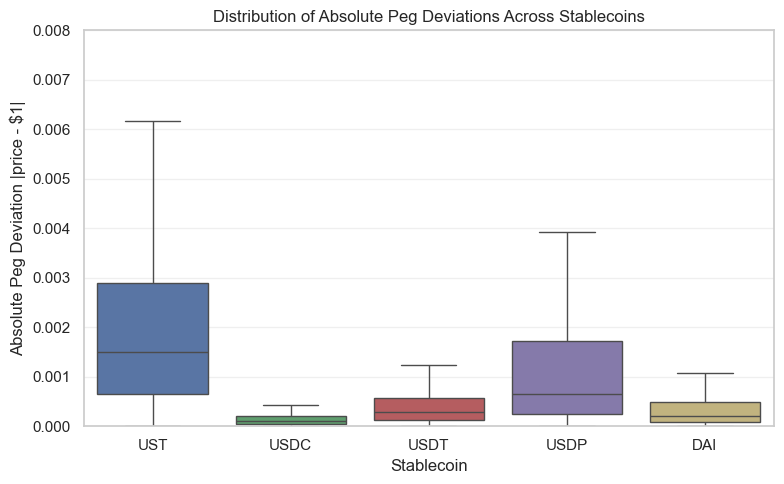

In [12]:
import seaborn as sns

df_plot = data.copy()
df_plot["abs_peg_error"] = abs(df_plot["close"] - 1)

# Standardise labels
df_plot["symbol"] = df_plot["symbol"].replace({"PAX": "USDP"})

coin_order = ["UST", "USDC", "USDT", "USDP", "DAI"]

palette = {
    "UST": "#4C72B0",   # blue (main focus)
    "USDC": "#55A868",  # green (stable)
    "USDT": "#C44E52",  # red-ish
    "USDP": "#8172B2",  # purple
    "DAI": "#CCB974"    # muted gold
}

fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=df_plot,
    x="symbol",
    y="abs_peg_error",
    order=coin_order,
    showfliers=False,
    palette=palette,
    ax=ax
)

# Zoom for visibility
ax.set_ylim(0, 0.01)

ax.set_xlabel("Stablecoin")
ax.set_ylabel("Absolute Peg Deviation |price - $1|")
ax.set_ylim(0, 0.008)
ax.set_title("Distribution of Absolute Peg Deviations Across Stablecoins")

ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Save
if fig_out_dir:
    fig.savefig(fig_out_dir / 'figure2_boxplot_abs_peg_error.png', dpi=300, bbox_inches='tight')